# DESCRIPTION

This notebook refers to the studies regarding the conformational explorations fo the substrates using HREX. In particular the first study is the interaction of the acceptor in the full-lenght protein. The idea is to try to sample bound conformation of the acceptor and get insights on the influence of the substrate to the closing mechanism. 

In [3]:
root="/mnt/d/PhD"

---

## HREX acceptor 

In [4]:
%cd $root/GlucTrans/GumK/Paper1/Acceptor_substrate/HREX/Starting

/mnt/d/PhD/GlucTrans/GumK/Paper1/Acceptor_substrate/HREX/Starting


In [5]:
import sys
sys.path.insert(1,f'{root}/bin/')
import hrex 
import MDAnalysis as mda
import os 
import numpy as np

the indices list is taken from pymol by using cmd.identify('sele')

In [25]:
acc=[3292, 3288, 3441, 3483, 3297, 3300, 3302, 3303, 3307, 3446, 3467, 3488, 3310, 3313, 3315, 3316, 3320, 3448, 3469, 3490, 3450, 3471, 3492, 3323, 3452, 3473, 3494, 3454, 3474, 3496, 3456, 3476, 3498, 3443, 3464, 3485, 3445, 3466, 3487, 3457, 3478, 3500, 3460, 3481, 3503, 3296, 3293, 3294, 3295, 3289, 3290, 3291, 3449, 3470, 3491, 3453, 3495, 3477, 3461, 3482, 3504, 3442, 3463, 3484, 3447, 3468, 3489, 3451, 3472, 3493, 3455, 3475, 3497, 3444, 3465, 3486, 3301, 3458, 3479, 3501, 3459, 3480, 3502, 3298, 3299, 3304, 3305, 3306, 3308, 3309, 3311, 3314, 3312, 3317, 3318, 3319, 3321, 3322, 3324, 3325, 3499, 3462]
acc=' '.join([str(i+2326) for i in acc])

In [26]:
binding_acc=[7, 8, 9, 38, 13, 18, 42, 45, 46, 48, 49, 50, 74, 75, 76, 77, 78, 79, 80, 81, 117, 118, 119, 120, 142, 143,140, 147 ,148, 149, 150, 151 ]
binding_acc=' '.join([str(i) for i in binding_acc])

In [27]:
nobb='15 272 300 303 304 178 172'

In [28]:
u=mda.Universe('md.pdb')
scaled=u.select_atoms(f'resid {binding_acc} and protein or (resid {nobb} and protein and not backbone and not name HN HA) or id {acc}')

In [29]:
pdb_ids=list(scaled.ids)

In [30]:
hrex.modify_atom_types('processed.top', 'md.pdb', pdb_ids, ['PROA', 'ACC'])
hrex.update_occupancy_factor_by_molecule('processed_modified.top', 'md.pdb', 'vis_scaled.pdb')

In [37]:
!echo -e "\n 1 | 13\nname 20 SOLU\n 14 | 15 | 16\nname 21 MEMB\n 17 | 18 | 19\nname 22 SOLV\n 20 | 21\nname 23 SOLU_MEMB\nq" | gmx make_ndx -f md.pdb 

               :-) GROMACS - gmx make_ndx, 2023.4-conda_forge (-:

Executable:   /home/davidelu/mambaforge/bin.AVX2_256/gmx
Data prefix:  /home/davidelu/mambaforge
Working dir:  /mnt/d/PhD/GlucTrans/GumK/Paper1/Acceptor_substrate/HREX/Starting
Command line:
  gmx make_ndx -f md.pdb


Reading structure file
Going to read 0 old index file(s)
Analysing residue names:
There are:   359    Protein residues
There are: 22894      Other residues
Analysing Protein...
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...

  0 System              : 100955 atoms
  1 Protein             :  5613 atoms
  2 Protein-H           :  2836 atoms
  3 C-alpha             :   359 atoms
  4 Backbone            :  1077 atoms
  5 MainChain           :  1435 atoms
  6 MainChain+Cb        :  1772 atoms
  7 MainChain+H         :  1771 atoms
  8 SideChain           :  3842 atoms
  9 SideChain-H         :  1401 atoms
 10 Prot-Masses         :  5613 atoms
 11 non-Protein         : 9534

In [40]:
scaled_str='  '.join([str(i) for i in scaled.ids])
scaled_str

'103  104  105  106  107  108  109  110  111  112  113  114  115  116  117  118  119  120  121  122  123  124  125  126  127  128  129  130  131  132  133  134  135  136  137  138  139  140  141  198  199  200  201  202  203  204  205  206  207  208  209  210  211  230  231  232  233  234  235  236  237  238  239  240  241  242  243  244  245  246  247  284  285  286  287  288  289  290  291  292  293  294  295  296  297  617  618  619  620  621  622  623  624  625  626  627  628  629  630  631  632  633  634  635  636  637  638  639  640  697  698  699  700  701  702  703  704  705  706  707  708  709  710  711  712  713  714  715  751  752  753  754  755  756  757  758  759  760  761  762  763  764  765  766  767  768  769  770  771  772  773  774  775  776  777  778  779  780  781  782  783  784  785  786  787  788  789  797  798  799  800  801  802  803  804  805  806  807  808  809  810  811  812  813  814  815  816  817  818  819  820  821  822  823  824  825  826  827  828  829 

In [42]:
!echo -e "\n 0 & ! 25 \nname 26 NOSCALED\nq" | gmx make_ndx -f md.pdb  -n index.ndx

               :-) GROMACS - gmx make_ndx, 2023.4-conda_forge (-:

Executable:   /home/davidelu/mambaforge/bin.AVX2_256/gmx
Data prefix:  /home/davidelu/mambaforge
Working dir:  /mnt/d/PhD/GlucTrans/GumK/Paper1/Acceptor_substrate/HREX/Starting
Command line:
  gmx make_ndx -f md.pdb -n index.ndx


Reading structure file
Going to read 1 old index file(s)
5822 5823 5824 5825 5826 5827 5828 5829 5830

  0 System              : 100955 atoms
  1 Protein             :  5613 atoms
  2 Protein-H           :  2836 atoms
  3 C-alpha             :   359 atoms
  4 Backbone            :  1077 atoms
  5 MainChain           :  1435 atoms
  6 MainChain+Cb        :  1772 atoms
  7 MainChain+H         :  1771 atoms
  8 SideChain           :  3842 atoms
  9 SideChain-H         :  1401 atoms
 10 Prot-Masses         :  5613 atoms
 11 non-Protein         : 95342 atoms
 12 Other               : 95342 atoms
 13 ACC                 :   217 atoms
 14 DYPG                :  2856 atoms
 15 DYPE                : 11

In [43]:
!scp index.ndx processed.top md.gro nmrbox:/home/nmrbox/0030/dluciano/full_prot/GumK/WT/acceptor/HREX/Sanity_Check/Sanity_Check1/WT/.

index.ndx                                     100% 3726KB   4.4MB/s   00:00    
processed.top                                 100% 2197KB   8.5MB/s   00:00    
md.gro                                        100% 6803KB  11.4MB/s   00:00    


### Sanity_Check1

In [7]:
%cd $root/GlucTrans/GumK/Paper1/Acceptor_substrate/HREX/Sanity_Check/Sanity_Check1/topologies

/mnt/d/PhD/GlucTrans/GumK/Paper1/Acceptor_substrate/HREX/Sanity_Check/Sanity_Check1/topologies


In [8]:
import sys
sys.path.insert(1,f'{root}/bin/')
import hrex 
import MDAnalysis as mda
import os 
import numpy as np

In [9]:
for i in [0.5, 1.0]:
    hrex.scale_top(i, '../../../Starting/processed_modified.top')

['C', 'NH1', 'CT1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'N', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'NH1', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'N', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'NH1', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'N', '1', '24', '24\\']


In [47]:
!scp topol_* nmrbox:/home/nmrbox/0030/dluciano/full_prot/GumK/WT/acceptor/HREX/Sanity_Check/Sanity_Check1/.

topol_0.5.top                                 100% 4544KB   5.9MB/s   00:00    
topol_1.0.top                                 100% 4224KB  10.4MB/s   00:00    


In [13]:
%cd $root/GlucTrans/GumK/Paper1/Acceptor_substrate/HREX/Sanity_Check/Sanity_Check1/

/mnt/d/PhD/GlucTrans/GumK/Paper1/Acceptor_substrate/HREX/Sanity_Check/Sanity_Check1


In [14]:
!mkdir REF 0.5 1.0

In [15]:
l=["REF","0.5","1.0"]
for i in l :
    os.chdir(i)
    for j in ['SCALED', 'NOSCALED']:
        os.makedirs(j)
        os.chdir(j)
        os.system(f'scp nmrbox:/home/nmrbox/0030/dluciano/full_prot/GumK/WT/acceptor/HREX/Sanity_Check/Sanity_Check1/{i}/{j}/*.xvg  .')
        os.chdir('../')
    os.chdir('../')

In [16]:
energy_term=['Bond', 'U-B', 'Proper Dih.', 'Improper Dih.', 'CMAP dih' ,'LJ-14', 'Coulomb-14', 'LJ (SR)', 'Disper. corr.', 'Coulomb (SR)', 'Coul. recip.', 'Potential']

In [17]:
data=np.loadtxt('./0.5/SCALED/energy.xvg').transpose()
data1=np.loadtxt('./REF/SCALED/energy.xvg').transpose()
for i in range(1,13):
    print(f'{energy_term[i-1]} = {round(np.average(data[i])/np.average(data1[i]),3)}')

Bond = 1.0
U-B = 1.0
Proper Dih. = 0.524
Improper Dih. = 0.5
CMAP dih = 0.5
LJ-14 = 0.5
Coulomb-14 = 0.5
LJ (SR) = 0.5
Disper. corr. = 0.5
Coulomb (SR) = 0.5
Coul. recip. = 0.5
Potential = 0.139


In [18]:
data=np.loadtxt('./0.5/NOSCALED/energy.xvg').transpose()
data1=np.loadtxt('./REF/NOSCALED/energy.xvg').transpose()
for i in range(1,13):
    print(f'{energy_term[i-1]} = {round(np.average(data[i])/np.average(data1[i]),6)}')

Bond = 1.0
U-B = 1.0
Proper Dih. = 1.0
Improper Dih. = 1.0
CMAP dih = 1.0
LJ-14 = 1.0
Coulomb-14 = 1.0
LJ (SR) = 1.0
Disper. corr. = 1.0
Coulomb (SR) = 1.0
Coul. recip. = 1.0
Potential = 1.0


So the binding reagion which is scaled is properly treated 

In [19]:
data=np.loadtxt('./1.0/SCALED/energy.xvg').transpose()
data1=np.loadtxt('./REF/SCALED/energy.xvg').transpose()
for i in range(1,13):
    print(f'{energy_term[i-1]} = {round(np.average(data[i])/np.average(data1[i]),6)}')

Bond = 1.0
U-B = 1.0
Proper Dih. = 1.04859
Improper Dih. = 1.0
CMAP dih = 1.0
LJ-14 = 0.999993
Coulomb-14 = 1.0
LJ (SR) = 0.999993
Disper. corr. = 1.0
Coulomb (SR) = 1.0
Coul. recip. = 1.0
Potential = 0.971479


So the binding reagion which is scaled is properly treated 

In [20]:
data=np.loadtxt('./1.0/NOSCALED/energy.xvg').transpose()
data1=np.loadtxt('./REF/NOSCALED/energy.xvg').transpose()
for i in range(1,13):
    print(f'{energy_term[i-1]} = {round(np.average(data[i])/np.average(data1[i]),6)}')

Bond = 1.0
U-B = 1.0
Proper Dih. = 1.0
Improper Dih. = 1.0
CMAP dih = 1.0
LJ-14 = 1.0
Coulomb-14 = 1.0
LJ (SR) = 1.0
Disper. corr. = 1.0
Coulomb (SR) = 1.0
Coul. recip. = 1.0
Potential = 1.0


### Test ladder

In [14]:
%cd $root/GlucTrans/GumK/Paper1/Acceptor_substrate/HREX/test_ladder/topologies

/mnt/d/PhD/GlucTrans/GumK/Paper1/Acceptor_substrate/HREX/test_ladder/topologies


In [15]:
import sys
sys.path.insert(1,f'{root}/bin/')
import hrex 
import numpy as np

In [16]:
lam = [round(i,3) for i in np.linspace(0.3, 1.0, 21)]
print(lam)

[0.3, 0.335, 0.37, 0.405, 0.44, 0.475, 0.51, 0.545, 0.58, 0.615, 0.65, 0.685, 0.72, 0.755, 0.79, 0.825, 0.86, 0.895, 0.93, 0.965, 1.0]


In [23]:
len(lam)

21

In [19]:
'" "'.join([str(i) for i in lam])

'0.3" "0.335" "0.37" "0.405" "0.44" "0.475" "0.51" "0.545" "0.58" "0.615" "0.65" "0.685" "0.72" "0.755" "0.79" "0.825" "0.86" "0.895" "0.93" "0.965" "1.0'

In [21]:
for i in lam:
    hrex.scale_top(i, '../../Starting/processed_modified.top')

['C', 'NH1', 'CT1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'N', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'NH1', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'N', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'NH1', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'N', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'NH1', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'N', '1', '24', '24\\']
['C', 'N', '

In [22]:
!scp topol_* nmrbox:/home/nmrbox/0030/dluciano/full_prot/GumK/WT/acceptor/HREX/test_ladder/prep/topologies/.

topol_0.3.top                                 100% 4557KB   6.3MB/s   00:00    
topol_0.335.top                               100% 4564KB  12.0MB/s   00:00    
topol_0.37.top                                100% 4561KB   9.6MB/s   00:00    
topol_0.405.top                               100% 4564KB  12.1MB/s   00:00    
topol_0.44.top                                100% 4560KB  12.0MB/s   00:00    
topol_0.475.top                               100% 4560KB  12.0MB/s   00:00    
topol_0.51.top                                100% 4560KB  12.1MB/s   00:00    
topol_0.545.top                               100% 4565KB  12.1MB/s   00:00    
topol_0.58.top                                100% 4564KB  11.9MB/s   00:00    
topol_0.615.top                               100% 4560KB  12.1MB/s   00:00    
topol_0.65.top                                100% 4560KB   9.3MB/s   00:00    
topol_0.685.top                               100% 4565KB  12.0MB/s   00:00    
topol_0.72.top                          

In [3]:
%cd $root/GlucTrans/GumK/Paper1/Acceptor_substrate/HREX/test_ladder/energy

/mnt/d/PhD/GlucTrans/GumK/Paper1/Acceptor_substrate/HREX/test_ladder/energy


In [4]:
import sys
sys.path.insert(1,f'/mnt/d/PhD/bin/')
import wham
import matplotlib.pyplot as plt
import numpy as np

In [5]:
lam = [round(i,3) for i in np.linspace(0.3, 1.0, 19)]
print(lam)

[0.3, 0.339, 0.378, 0.417, 0.456, 0.494, 0.533, 0.572, 0.611, 0.65, 0.689, 0.728, 0.767, 0.806, 0.844, 0.883, 0.922, 0.961, 1.0]


In [6]:
!scp nmrbox:/home/nmrbox/0030/dluciano/full_prot/GumK/WT/acceptor/HREX/test_ladder/HREX/analysis/*.xvg .

energy_0.xvg                                  100%  557KB   1.2MB/s   00:00    
energy_10.xvg                                 100%  557KB   2.2MB/s   00:00    
energy_11.xvg                                 100%  557KB   3.9MB/s   00:00    
energy_12.xvg                                 100%  557KB   4.0MB/s   00:00    
energy_13.xvg                                 100%  557KB   4.0MB/s   00:00    
energy_14.xvg                                 100%  557KB   4.0MB/s   00:00    
energy_15.xvg                                 100%  557KB   4.1MB/s   00:00    
energy_16.xvg                                 100%  557KB   4.1MB/s   00:00    
energy_17.xvg                                 100%  557KB   4.2MB/s   00:00    
energy_18.xvg                                 100%  557KB   4.2MB/s   00:00    
energy_1.xvg                                  100%  557KB   4.0MB/s   00:00    
energy_2.xvg                                  100%  557KB   3.9MB/s   00:00    
energy_3.xvg                            

In [7]:
energies=[]
for i in range(len(lam)):
    energies.append(np.loadtxt(f"energy_{i}.xvg".format(i),usecols=1))
energies=np.array(energies).T

In [8]:
energies.shape

(19019, 19)

In [9]:
kBT=0.00831446261815324*300
w=wham.wham(energies,T=kBT)
# w["logW"] are the Boltzmann factors
# notice that we did not specify yet to which ensemble we are reweighting
# this can be done with the following line:
logW=w["logW"]-energies[:,0]/kBT
# logW are the logaritm weights to obtain properties corresponding to replica 0
logW-=np.max(logW) # avoid numerical errors in exp
weights=np.exp(logW)
weights/=np.sum(weights) # normalize weights
# these weights can be used to compute weighted average'log's
w['logW']=list(w['logW'])
w['logZ']=list(w['logZ'])

In [10]:
coefficients=[]
for i in range(energies.shape[0]):
    c=np.polyfit(np.sqrt(lam),energies[i],2)
    coefficients.append(c)
coefficients=np.array(coefficients)
residual=np.dot(coefficients, np.array((lam,np.sqrt(lam),np.ones(len(lam)))))-energies

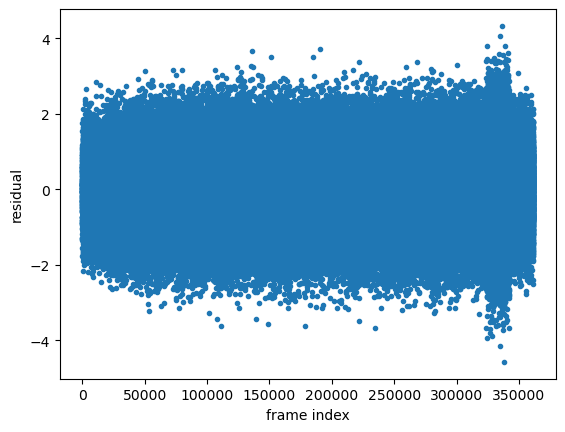

In [11]:
# This is the residual, very small
plt.plot(residual.T.flatten(),".")
plt.xlabel("frame index")
plt.ylabel("residual")
plt.show()

In [12]:
def predict_acceptance(l1,l2):
    # energies corresponding to l1 and l2, using the interpolated function
    e1=coefficients[:,0]*l1+coefficients[:,1]*np.sqrt(l1)+coefficients[:,2]
    e2=coefficients[:,0]*l2+coefficients[:,1]*np.sqrt(l2)+coefficients[:,2]
    
    # weights corresponding to l1 and l2
    logW1=w["logW"]-e1/kBT
    logW2=w["logW"]-e2/kBT
    logW1-=np.max(logW1)
    logW2-=np.max(logW2)
    w1=np.exp(logW1)
    w2=np.exp(logW2)
    w1/=np.sum(w1)
    w2/=np.sum(w2)
    
    # then we have to compute the average of the acceptance, which means the average of:
    # np.minimum(w1[j]*w2[i]/(w1[i]*w2[j]),1.0)
    # (compare with Metropolis rule)
    
    # We can do it in two ways. One way is to randomly sample a number (10000, below)
    # of frames from the two ensembles and using them to compute the average acceptance.
    
    #c1=np.random.choice(len(w1),10000,p=w1)
    #c2=np.random.choice(len(w2),10000,p=w2)
    #a=np.minimum(w1[c2]*w2[c1]/(w1[c1]*w2[c2]),1.0)
    #return np.average(a)
    
    # the problem of this approach is that it is random, thus not good to construct a function to be minimized
    
    # alternatively we consider all pairs of frame, with a skip (5) here to just run faster
    w1=w1[::5]
    w2=w2[::5]
    a=[]
    for i in range(len(w1)):
        if 0 in w1[i]*w2[:]:
            a.append(np.average(np.minimum(w1[:]*w2[i]/(1.00e-300),1.0),weights=w2))
        else:
            a.append(np.average(np.minimum(w1[:]*w2[i]/(w1[i]*w2[:]),1.0),weights=w2))
    return np.average(a,weights=w1)  

In [13]:
for i in range(len(lam)-1):
    print(predict_acceptance(lam[i],lam[i+1]))

0.0304696228599138
0.05967548500171112
0.08875766058698009
0.08474592119272943
0.1275581953174835
0.14390867351357292
0.15659969864512494
0.1912500142485765
0.17332636425834388
0.2123487621739403
0.22138679218591678
0.2266435362083437
0.2752687368544853
0.3101581992108798
0.2957706088970549
0.30966176799643597
1.0
1.0


As we can see the prediction doesn't work in this case, and it is probably due to the too uneven distirbution used for the testing e.g. the liear distibution. We can try a different approch; generating a starting distribution using the function which modify the geometric distribution with an alpha of 0.65 which should be a good stating guess and test for 1 ns if it works. 

### New Test

In [11]:
%cd $root/GlucTrans/GumK/Paper1/Acceptor_substrate/HREX/test2_ladder/topologies

/mnt/d/PhD/GlucTrans/GumK/Paper1/Acceptor_substrate/HREX/test2_ladder/topologies


In [12]:
import sys
sys.path.insert(1,f'{root}/bin/')
import hrex 
import numpy as np

In [13]:
T_new = 1000
t_new = 300
N = 25

x_values = np.linspace(0, N-1, N)

def f_corrected(x, t, T, N):
    return t / (t * np.exp((x * np.log(T / t)) / (N - 1)))

# Calculate distribution values for the new parameters
corrected_distribution_values_new = f_corrected(x_values, t_new, T_new, N)

def f_adjusted_steepness(x, t, T, N, alpha):
    return t / (t * np.exp(alpha * (x * np.log(T / t)) / (N - 1)))

# Steepness factor
alpha = 0.65

# Calculate distribution values for the adjusted function with increased steepness
adjusted_distribution_values_steepness = f_adjusted_steepness(x_values, t_new, T_new, N, alpha)

original_min, original_max = np.min(corrected_distribution_values_new), np.max(corrected_distribution_values_new)

# Calculate the min and max of the adjusted distribution
adjusted_min, adjusted_max = np.min(adjusted_distribution_values_steepness), np.max(adjusted_distribution_values_steepness)

# Scale the adjusted distribution to have the same min and max as the original
scaled_distribution_values_steepness = ((adjusted_distribution_values_steepness - adjusted_min) / (adjusted_max - adjusted_min)) * (original_max - original_min) + original_min

corrected_distribution_values_new.sort()
scaled_distribution_values_steepness.sort()
scaled_distribution_values_steepness=[round(i,3) for i in scaled_distribution_values_steepness]

In [14]:
len(scaled_distribution_values_steepness)

25

In [15]:
'" "'.join([str(i) for i in scaled_distribution_values_steepness])

'0.3" "0.32" "0.34" "0.361" "0.382" "0.404" "0.427" "0.451" "0.476" "0.501" "0.527" "0.554" "0.582" "0.611" "0.641" "0.672" "0.704" "0.737" "0.771" "0.806" "0.842" "0.88" "0.919" "0.959" "1.0'

In [16]:
for i in scaled_distribution_values_steepness:
    hrex.scale_top(i, '../../Starting/processed_modified.top')

['C', 'NH1', 'CT1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'N', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'NH1', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'N', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'NH1', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'N', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'NH1', '1', '24', '24\\']
['C', 'N', 'CP1', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT2', 'C', 'N', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'NH1', '1', '24', '24\\']
['C', 'NH1', 'CT1', 'C', 'N', '1', '24', '24\\']
['C', 'N', '

In [17]:
!scp topol_* nmrbox:/home/nmrbox/0030/dluciano/full_prot/GumK/WT/acceptor/HREX/test2_ladder/prep/topologies/.

topol_0.3.top                                 100% 4557KB   5.5MB/s   00:00    
topol_0.32.top                                100% 4562KB  12.0MB/s   00:00    
topol_0.34.top                                100% 4565KB  12.1MB/s   00:00    
topol_0.361.top                               100% 4566KB  12.0MB/s   00:00    
topol_0.382.top                               100% 4565KB  12.1MB/s   00:00    
topol_0.404.top                               100% 4567KB  12.0MB/s   00:00    
topol_0.427.top                               100% 4562KB  12.1MB/s   00:00    
topol_0.451.top                               100% 4566KB  12.2MB/s   00:00    
topol_0.476.top                               100% 4566KB  10.8MB/s   00:00    
topol_0.501.top                               100% 4565KB  12.1MB/s   00:00    
topol_0.527.top                               100% 4566KB  12.1MB/s   00:00    
topol_0.554.top                               100% 4569KB  11.9MB/s   00:00    
topol_0.582.top                         

[0.3, 0.325, 0.352, 0.379, 0.408, 0.438, 0.469, 0.501, 0.534, 0.569, 0.605, 0.642, 0.681, 0.721, 0.764, 0.807, 0.853, 0.9, 0.949, 1.0]


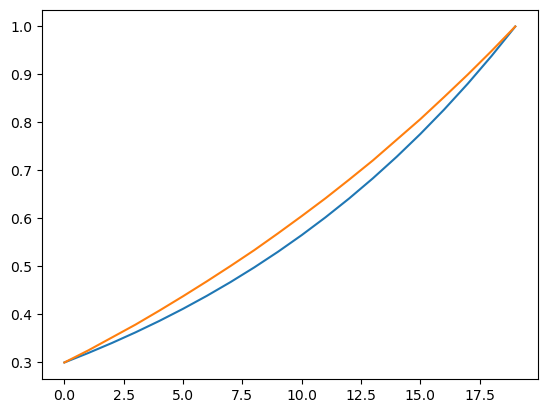

In [23]:
plt.figure()

plt.plot(corrected_distribution_values_new)
plt.plot(scaled_distribution_values_steepness)
print(scaled_distribution_values_steepness)

In [24]:
ps=[]
for i in range(len(scaled_distribution_values_steepness)-1):
    ps.append(predict_acceptance(round(scaled_distribution_values_steepness[i],3),round(scaled_distribution_values_steepness[i+1],3)))
ps=np.array(ps)

pgl=[]
for i in range(len(corrected_distribution_values_new)-1):
    pgl.append(predict_acceptance(corrected_distribution_values_new[i],corrected_distribution_values_new[i+1]))
pgl=np.array(pgl)

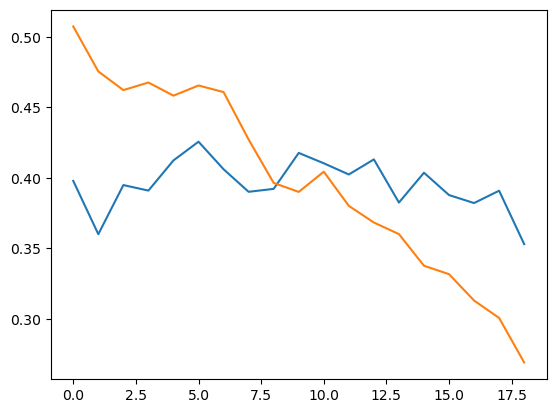

In [25]:
plt.figure()
plt.plot(ps)
plt.plot(pgl)
